# Forward-model comparison: magnetic dipole vs. electric current dipole

This example is the direct analogue of `basic_forward_model_example.ipynb`, but it
reconstructs the **same real recording** under **two different forward models** and
compares the recovered source-moment trajectories.

| model | field law | falloff | angular dependence |
|---|---|---|---|
| **magnetic dipole** (default) | $B = \frac{\mu_0}{4\pi}\frac{3(\mathbf{m}\cdot\hat{r})\hat{r} - \mathbf{m}}{r^3}$ | $\propto 1/r^3$ | $3(\mathbf{m}\cdot\hat r)\hat r - \mathbf m$ |
| **current dipole** (Biot–Savart) | $B = \frac{\mu_0}{4\pi}\frac{\mathbf{Q}\times\mathbf d}{\vert\mathbf d\vert^3}$ | $\propto 1/r^2$ | $\mathbf{Q}\times\hat r$ |

The magnetic-dipole model was originally chosen because the magnetic field is largely
insensitive to the volume conductor. But the heart is physically an **equivalent
current dipole**, and the current-dipole moment $\mathbf{Q}(t)$ *is* the
vectorcardiogram (VCG). The hypothesis: reconstructing the measured field with a
current-dipole forward yields a moment trajectory that is a more faithful VCG-like
representation.

**Everything but the forward model is reused.** The current-dipole model
(`CurrentDipoleForwardModel`) is a drop-in replacement selected via
`InverseSolver(source_model="current")`; the basis, initialization, solver, and all
plotting/HR/VCG utilities are unchanged. The free-space Biot–Savart operator is the
torch port of `leadfield_free_B` in
`fMCG_simulator/physics_simulation/forward_analytic.py`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add the parent directory (which contains the fmcg package) to Python path
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import fmcg
from fmcg.pipeline.preprocessing import load_and_preprocess
from fmcg.fitting.inverse_solver import InverseSolver
from fmcg.utils.plotting.plot_utils import (
    plot_magnetic_moments,
    plot_magnetic_moments_separate_axes,
    plot_sensor_signals,
    plot_vcg,
    plot_dipole_positions_3d,
)
from fmcg.analysis.hr import compute_hr
from fmcg.analysis.heartbeat_averaging import find_segments_and_average_heartbeats

logging.basicConfig(level=logging.ERROR, format="%(message)s", force=True)
DEVICE = "cpu"
print("device:", DEVICE)

device: cpu


## Data loading and preprocessing

Identical to `basic_forward_model_example.ipynb` — the same recording, whitening, and
downsampling. The measured field is the ground truth both models must explain.

Preprocessed signal: 297.1s at 200 Hz, 24 valid channels


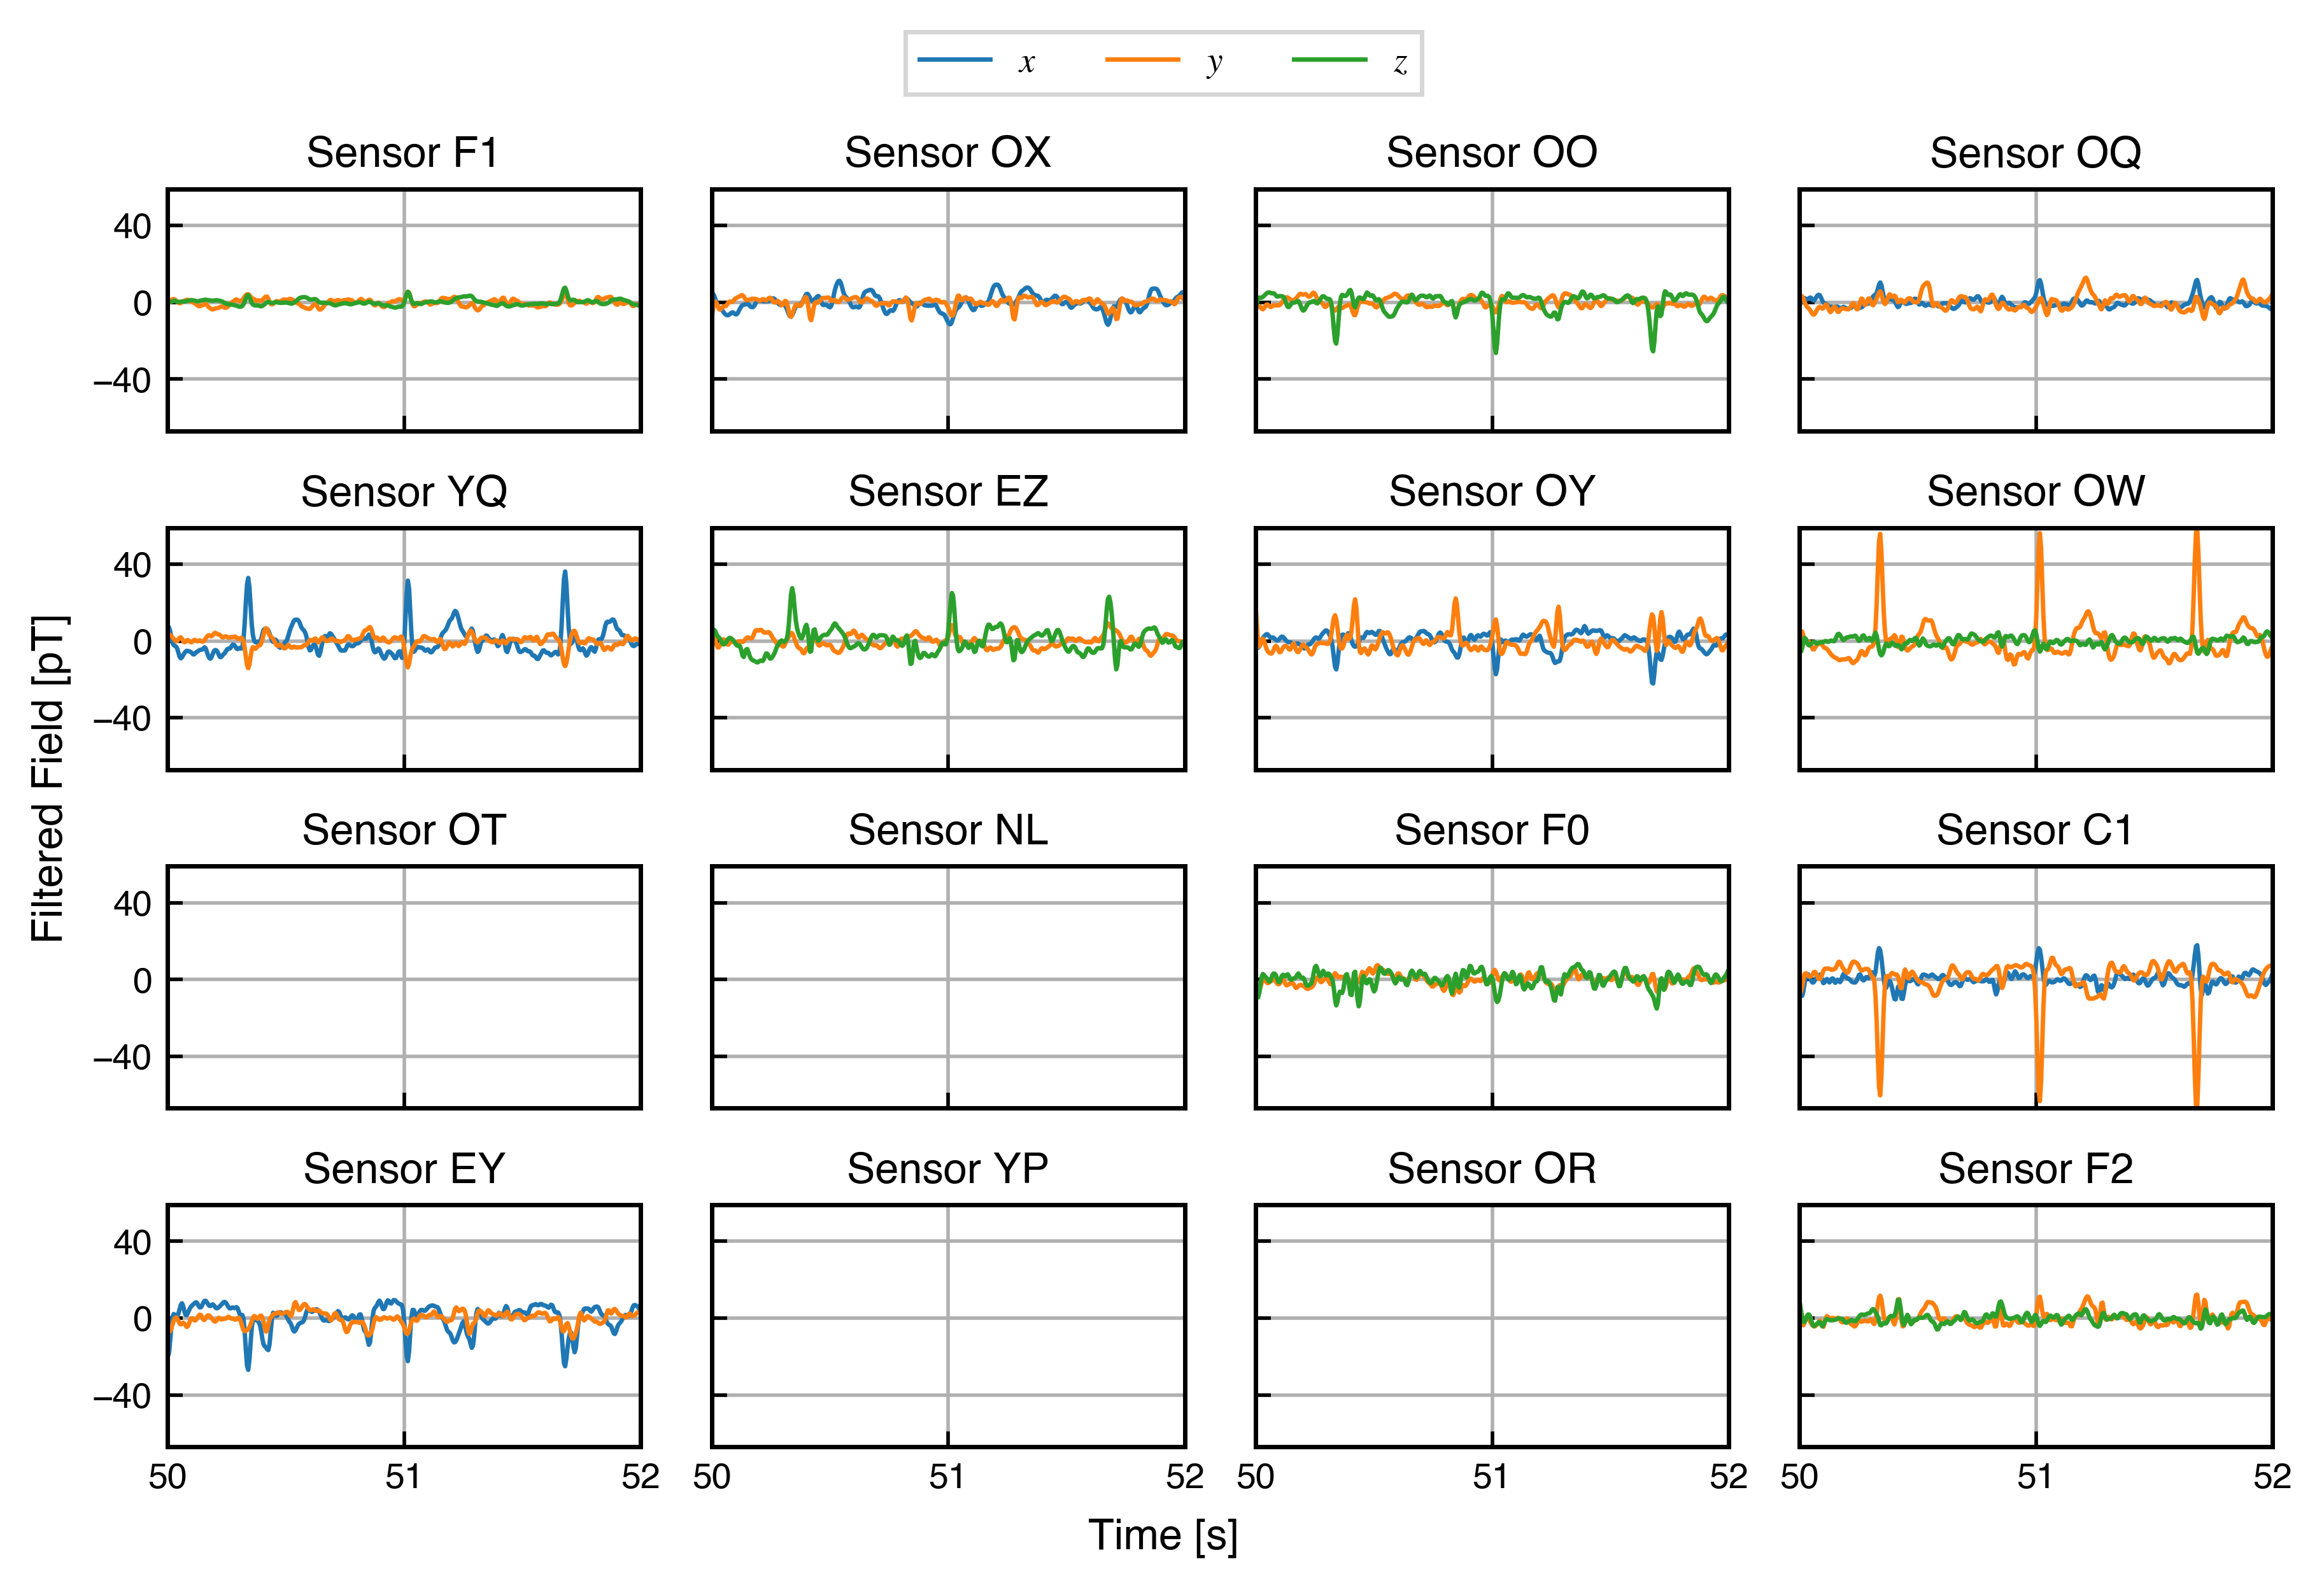

In [5]:
DS_PATH = "/fMCG_data/fMCG"

field_maps, noise_maps, axis_mask, W_n, fs, time, r_sensors, artifacts_mask, sensor_names = load_and_preprocess(
    ds_path=DS_PATH,
    patient="P097",
    series="S07",
    sig_group_names="R001",
    noise_group_names="R004",
    whitening="PCA",
    downsample_factor=5,  # 1000 → 200 Hz
)

print(f"Preprocessed signal: {field_maps.shape[0]/fs:.1f}s at {fs} Hz, {int(axis_mask.sum())} valid channels")

plot_sensor_signals(field_maps, time, ylabel="Filtered Field [pT]", xlim=[50, 52], sharey=True, sensor_names=sensor_names)

## Solver setup (shared by both models)

Same position bounds, initial guess, fitting window, and optimizer config as the base
example. Only `source_model` differs between the two reconstructions.

In [6]:
# Position bounds [dipole, coord] -> (min, max) in metres (fetal, maternal)
r_bnds = np.array([
    [(-0.3, 0.3), (-0.3, -0.005), (-0.3, 0.3)],
    [(-0.3, 0.3), (-0.3, -0.005), (0.1, 0.6)],
])
r_init = np.array([[[0, -0.02, 0.0], [0, -0.05, 0.2]]])

# Fit window
t_start, t_end = 60, 90  # seconds
window_mask = (time >= t_start) & (time <= t_end)
field_window = field_maps[window_mask, :, :]
time_window = time[window_mask]
print(f"Fitting window: {t_start}-{t_end}s ({field_window.shape[0]} samples)")

config = {
    "lr_groups": [1e-1, 1e-1, 1e-2],   # [lr_m_dipole0, lr_m_dipole1, lr_r]
    "patience_groups": [20],
    "niter": 500,
    "warmup": 50,
    "early_stopping_patience": 50,
    "early_stopping_threshold": 1e-8,
    "min_iter": 100,
    "corr_m_weight": 5e-1,
}

Fitting window: 60-90s (6000 samples)


In [11]:
def run_reconstruction(source_model, plot=False):
    """Reconstruct the fetal + maternal source moments under a given forward model.

    source_model: "magnetic" (magnetic dipole, ~1/r^3) or "current" (current
    dipole / Biot-Savart, ~1/r^2). Returns (m_hat, r_hat), each (T, 2, 3).
    """
    r_basis_args = {"basis": "sigmoid_time_constant", "n_time": time_window.shape[0], "bnds": r_bnds}

    solver = InverseSolver(
        r_sensors=r_sensors,
        method="lamb",
        num_dipoles=2,
        axis_mask=axis_mask,
        scaling=dict(m=[1e0, 1e0]),
        basis=dict(r=r_basis_args),
        bnds=dict(r=r_bnds),
        whitening_matrix=W_n,
        device=DEVICE,
        verbose=False,
        source_model=source_model,
    )

    field_tensor = torch.tensor(field_window, dtype=torch.float32, device=solver.device)
    r_init_repeated = np.repeat(r_init, field_tensor.shape[0], axis=0)
    r_init_tensor = torch.tensor(r_init_repeated, dtype=torch.float32, device=solver.device)

    initial_parameters, field_scaled = solver.initialize_parameters(
        r_init_tensor, field_tensor, field_scaling=1e0,
        method="pseudo_inv_regularized", rcond=1e0,
        determine_scaling=True, update_m_scaling=True,
    )

    m_hat, r_hat = solver.solve_with_config(
        field_scaled, initial_parameters, config, plot=plot, early_stop=True
    )
    print(f"[{source_model}] done — m_hat {m_hat.shape}, r_hat {r_hat.shape}")
    return m_hat, r_hat


m_mag, r_mag = run_reconstruction("magnetic")
m_cur, r_cur = run_reconstruction("current")

Iterations: 100%|██████████| 550/550 [03:10<00:00,  2.89it/s, Best Loss=0.0917]


[magnetic] done — m_hat (6000, 2, 3), r_hat (6000, 2, 3)


Iterations: 100%|██████████| 550/550 [00:28<00:00, 19.52it/s, Best Loss=0.116]

[current] done — m_hat (6000, 2, 3), r_hat (6000, 2, 3)


## Compare recovered moments

Fetal (dipole 0) and maternal (dipole 1) moment traces over the same window. Note the
moments are latent up to scale (the forward operators differ), so compare *shape*, not
absolute amplitude.

Magnetic-dipole reconstruction


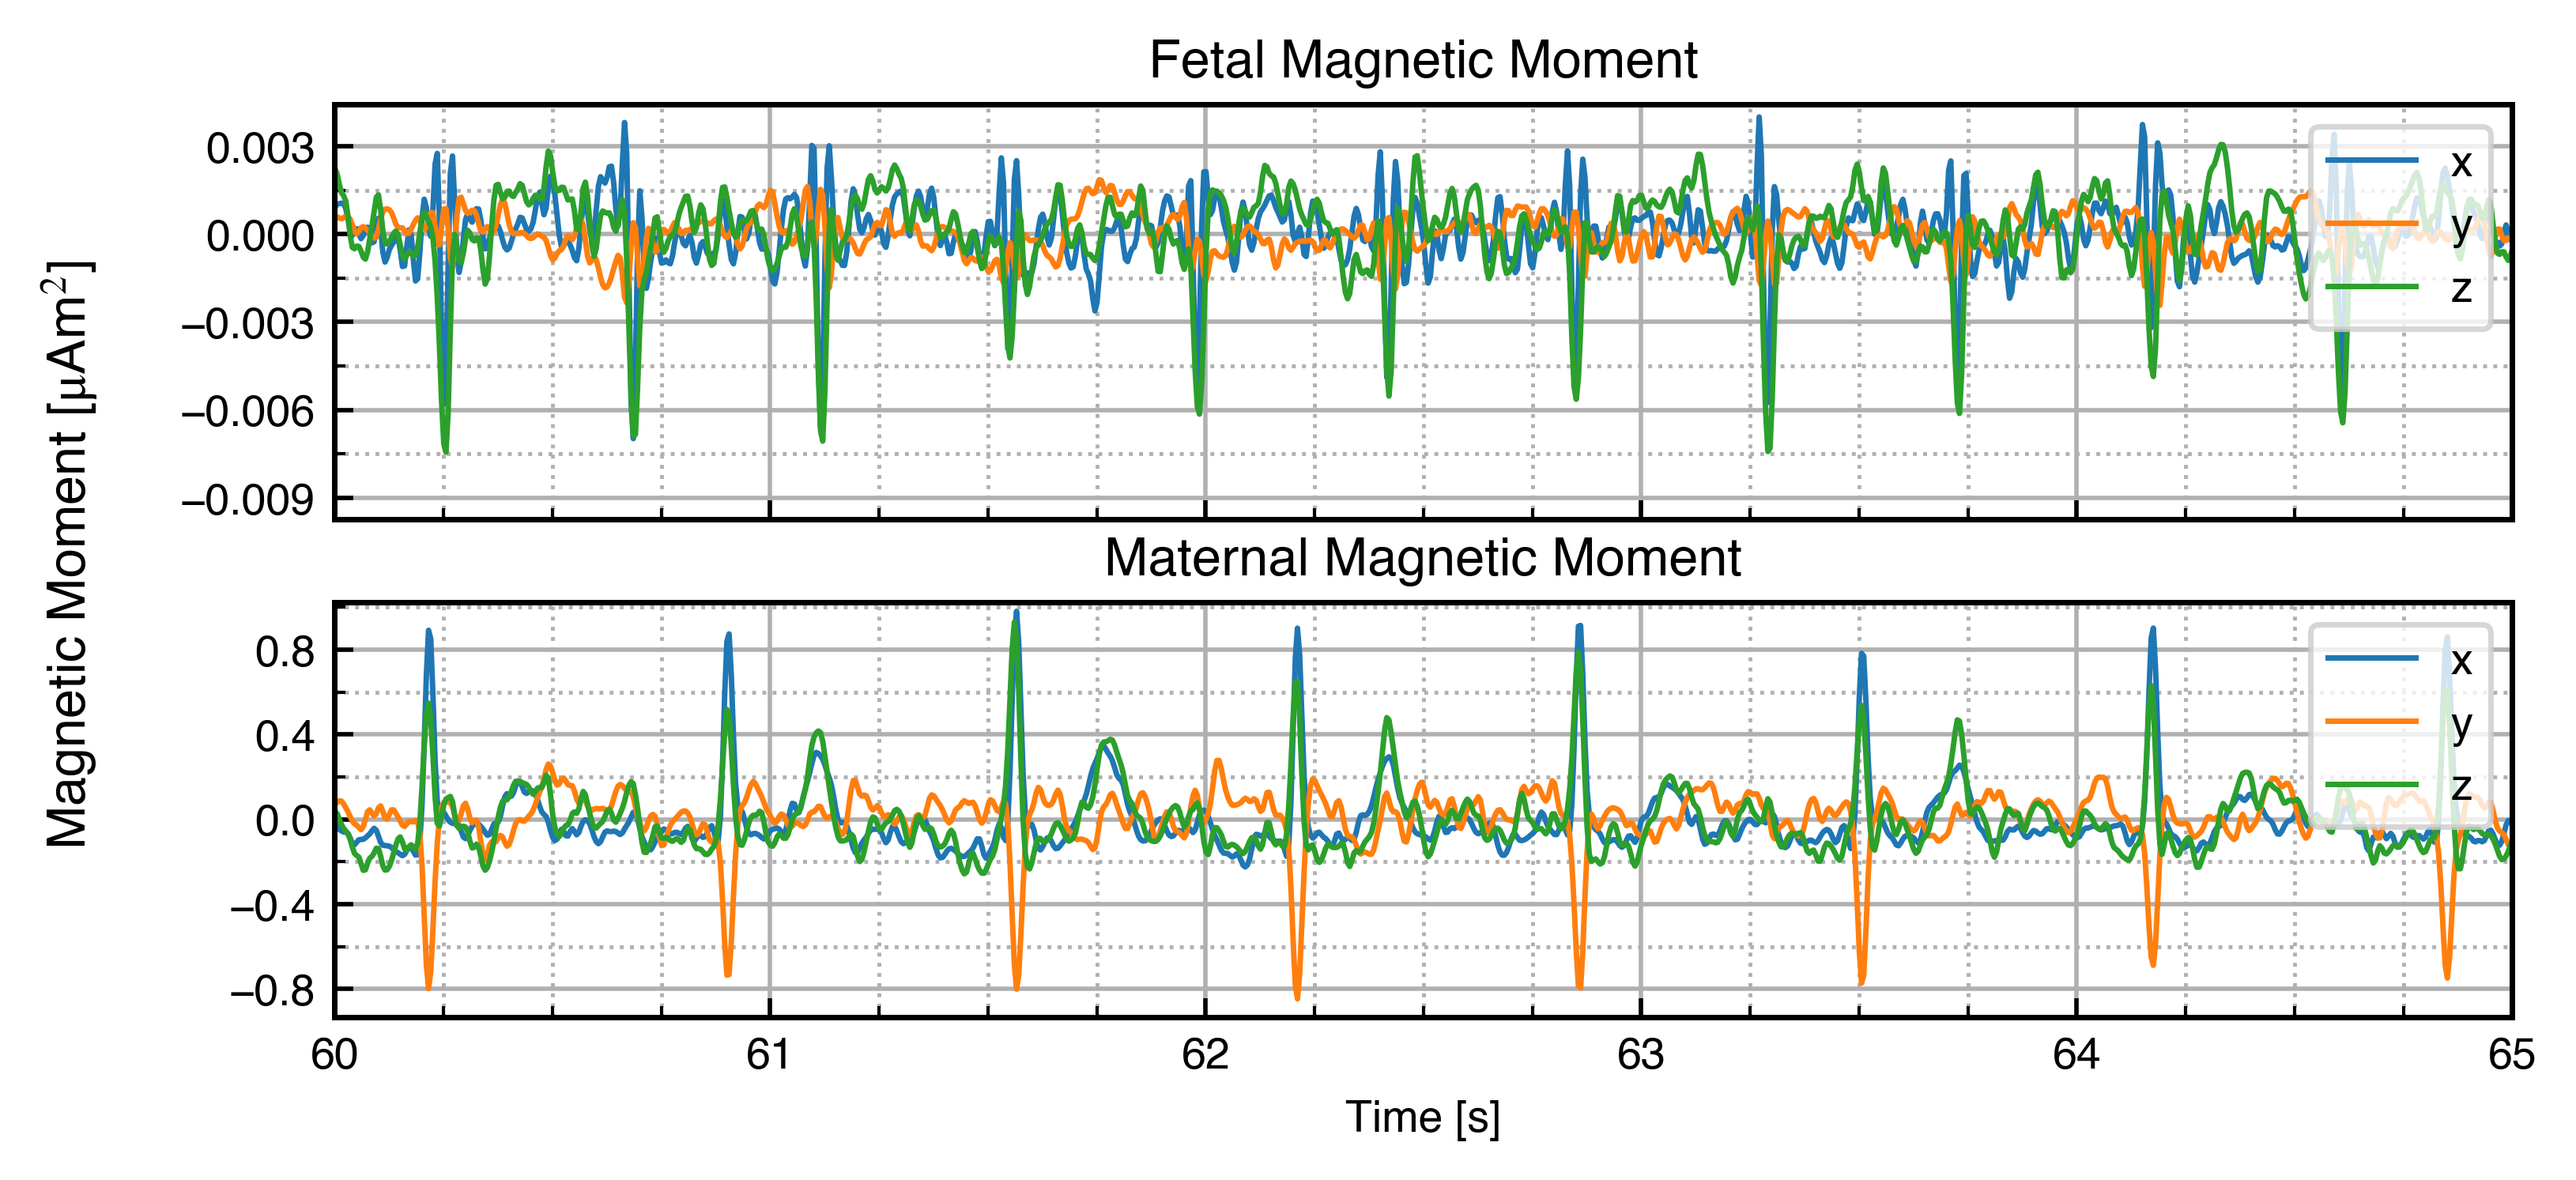

Current-dipole reconstruction


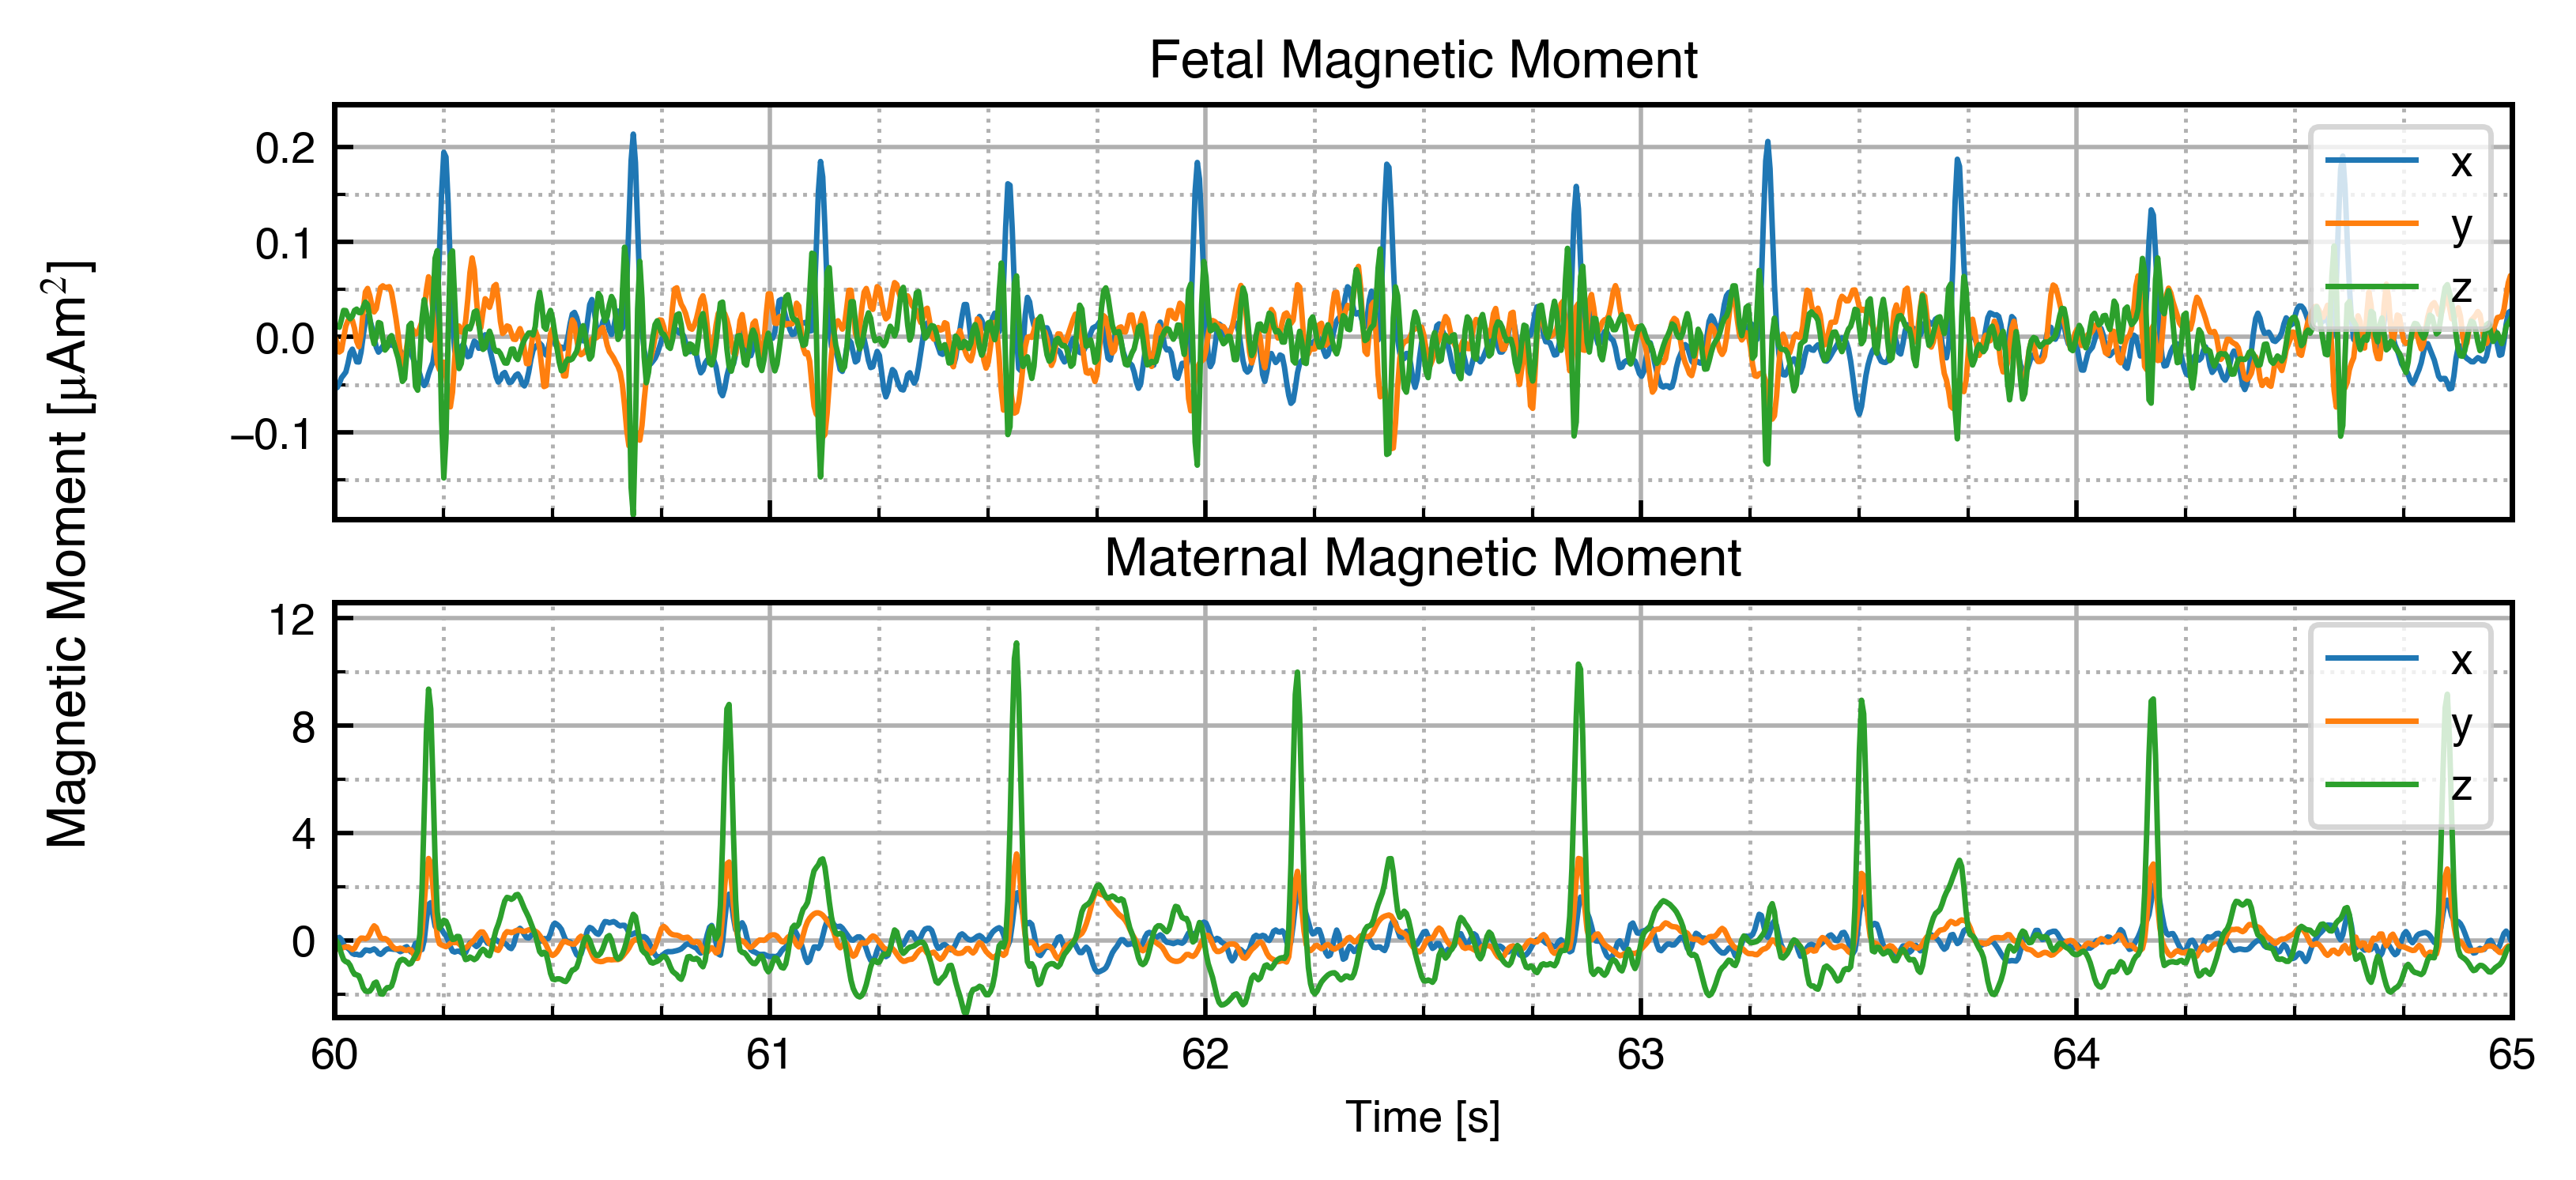

In [8]:
print("Magnetic-dipole reconstruction")
plot_magnetic_moments(m_mag, time=time_window, xlim=[60, 65], preprocess_method="biosppy")

print("Current-dipole reconstruction")
plot_magnetic_moments(m_cur, time=time_window, xlim=[60, 65], preprocess_method="biosppy")

## The payoff: averaged fetal VCG loop

Detect fetal beats from the reconstructed fetal moment, average them, and render the
3-D loop. The current-dipole moment is (up to scale) the equivalent current dipole of
the fetal heart, so its averaged loop should read as a more VCG-like trajectory.

/jonas/fmcg/fmcg/analysis/heartbeat_averaging.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


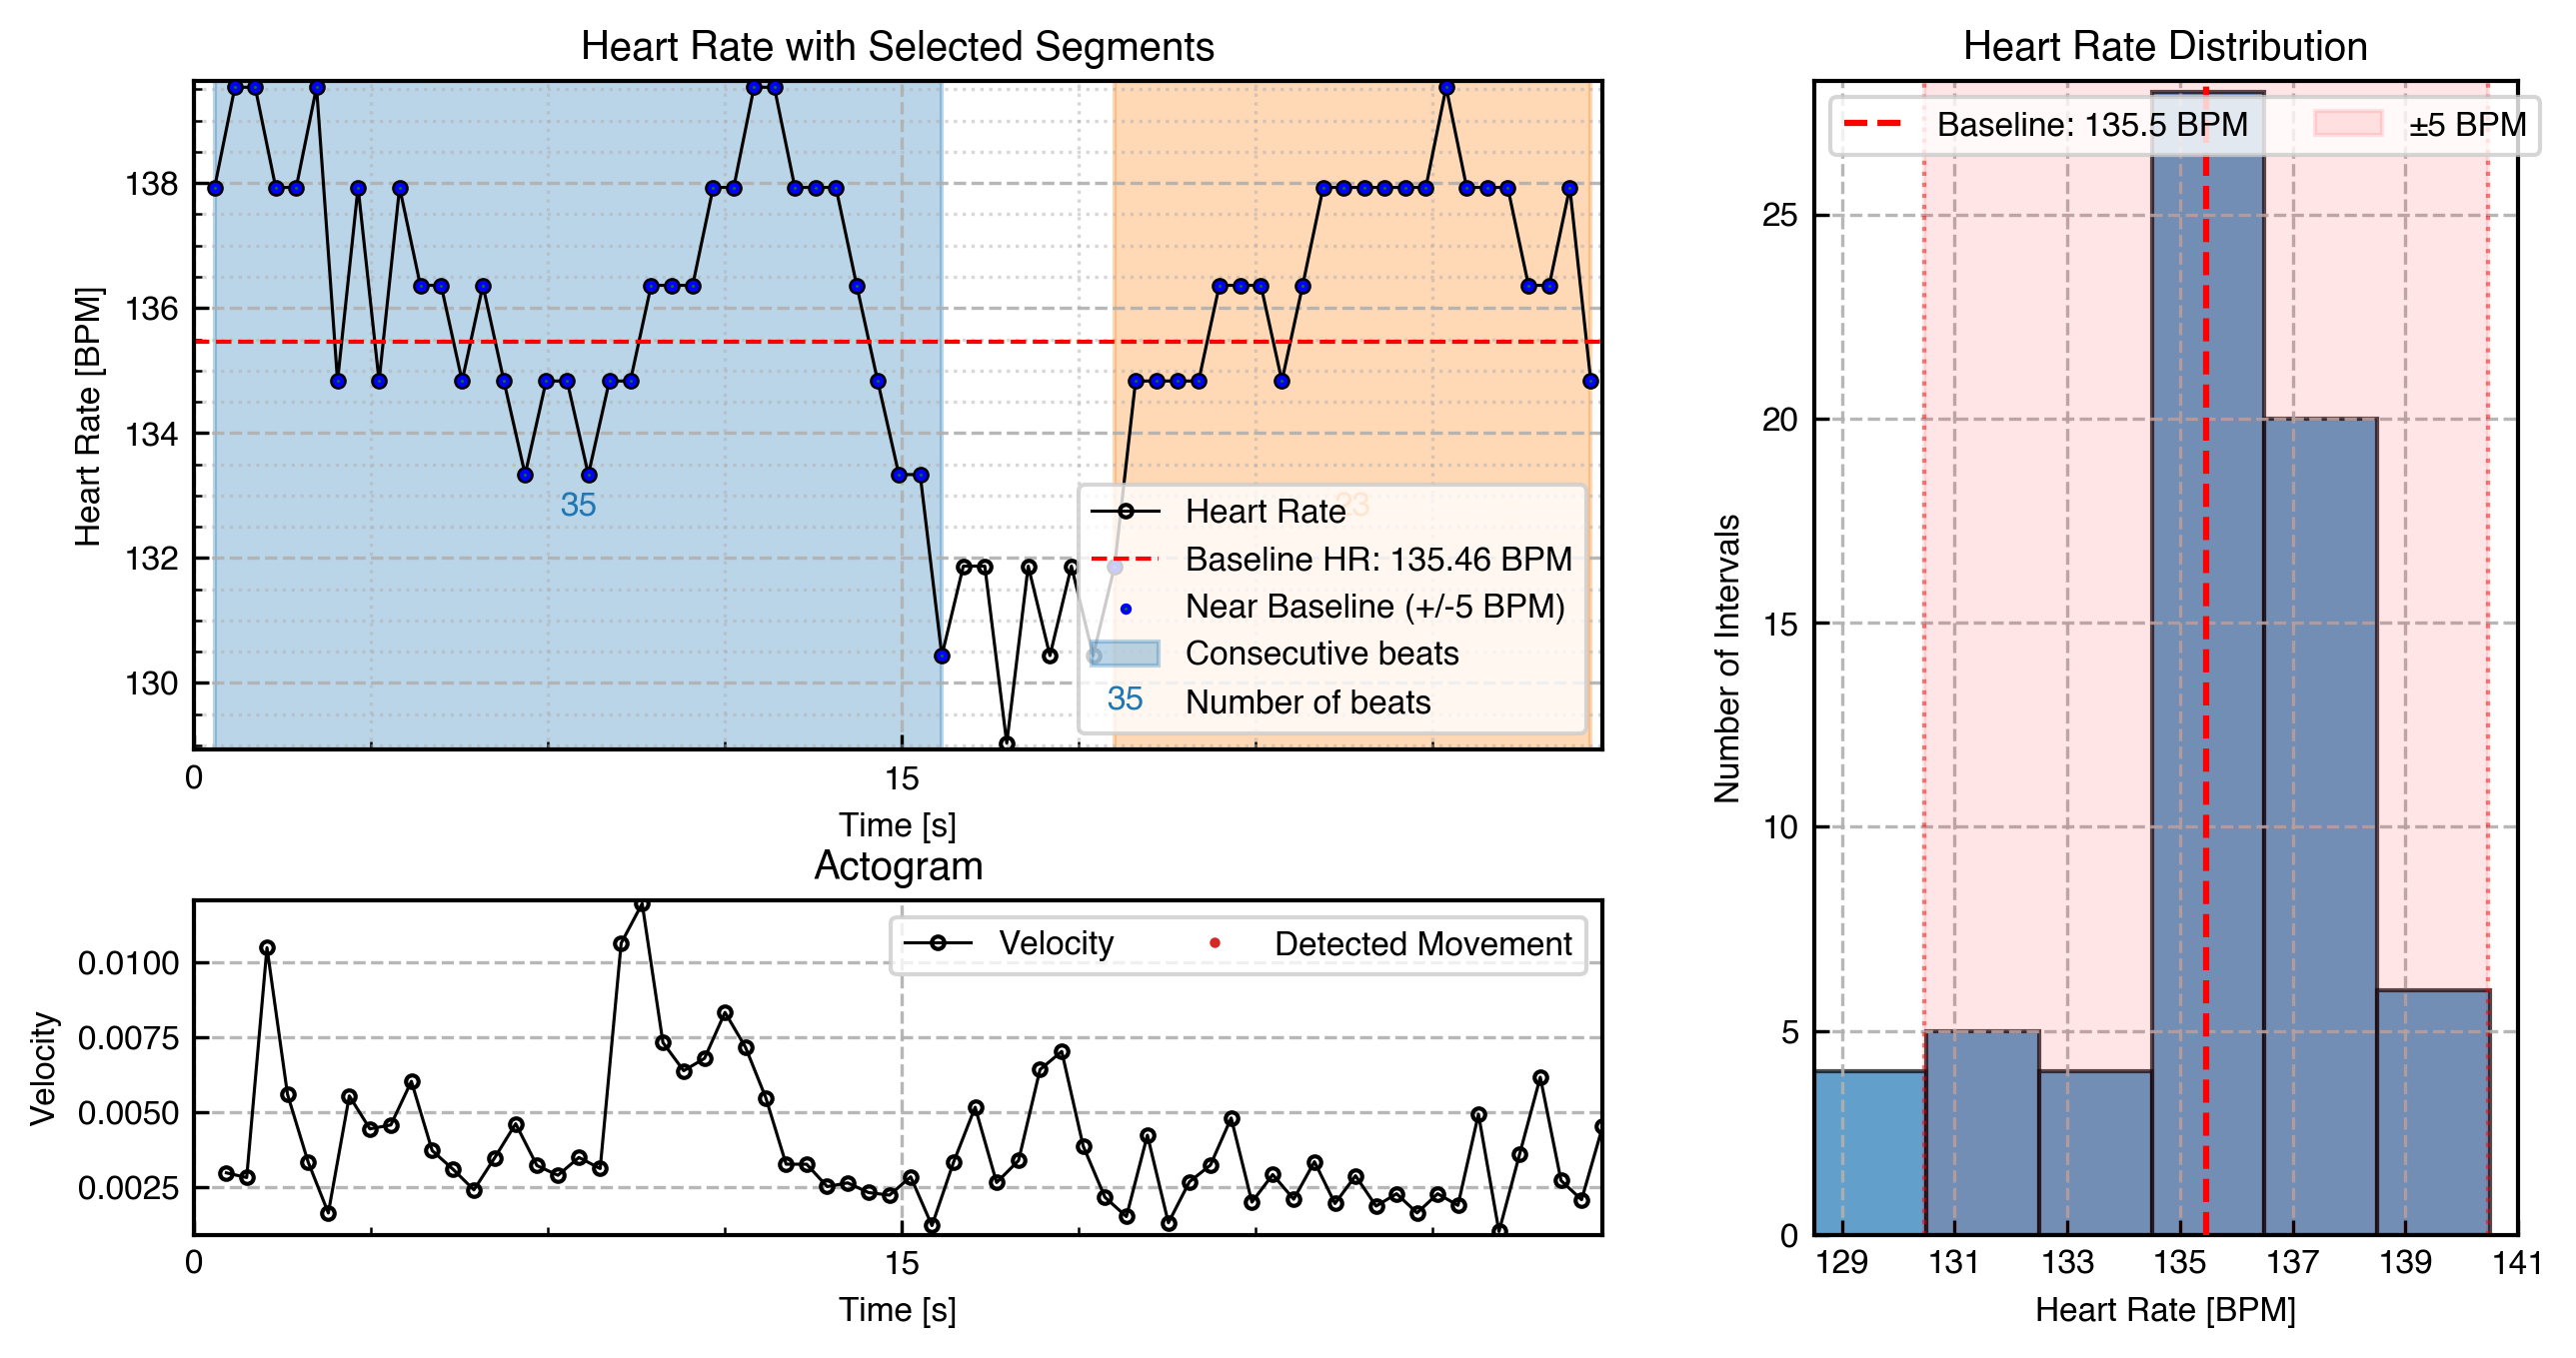

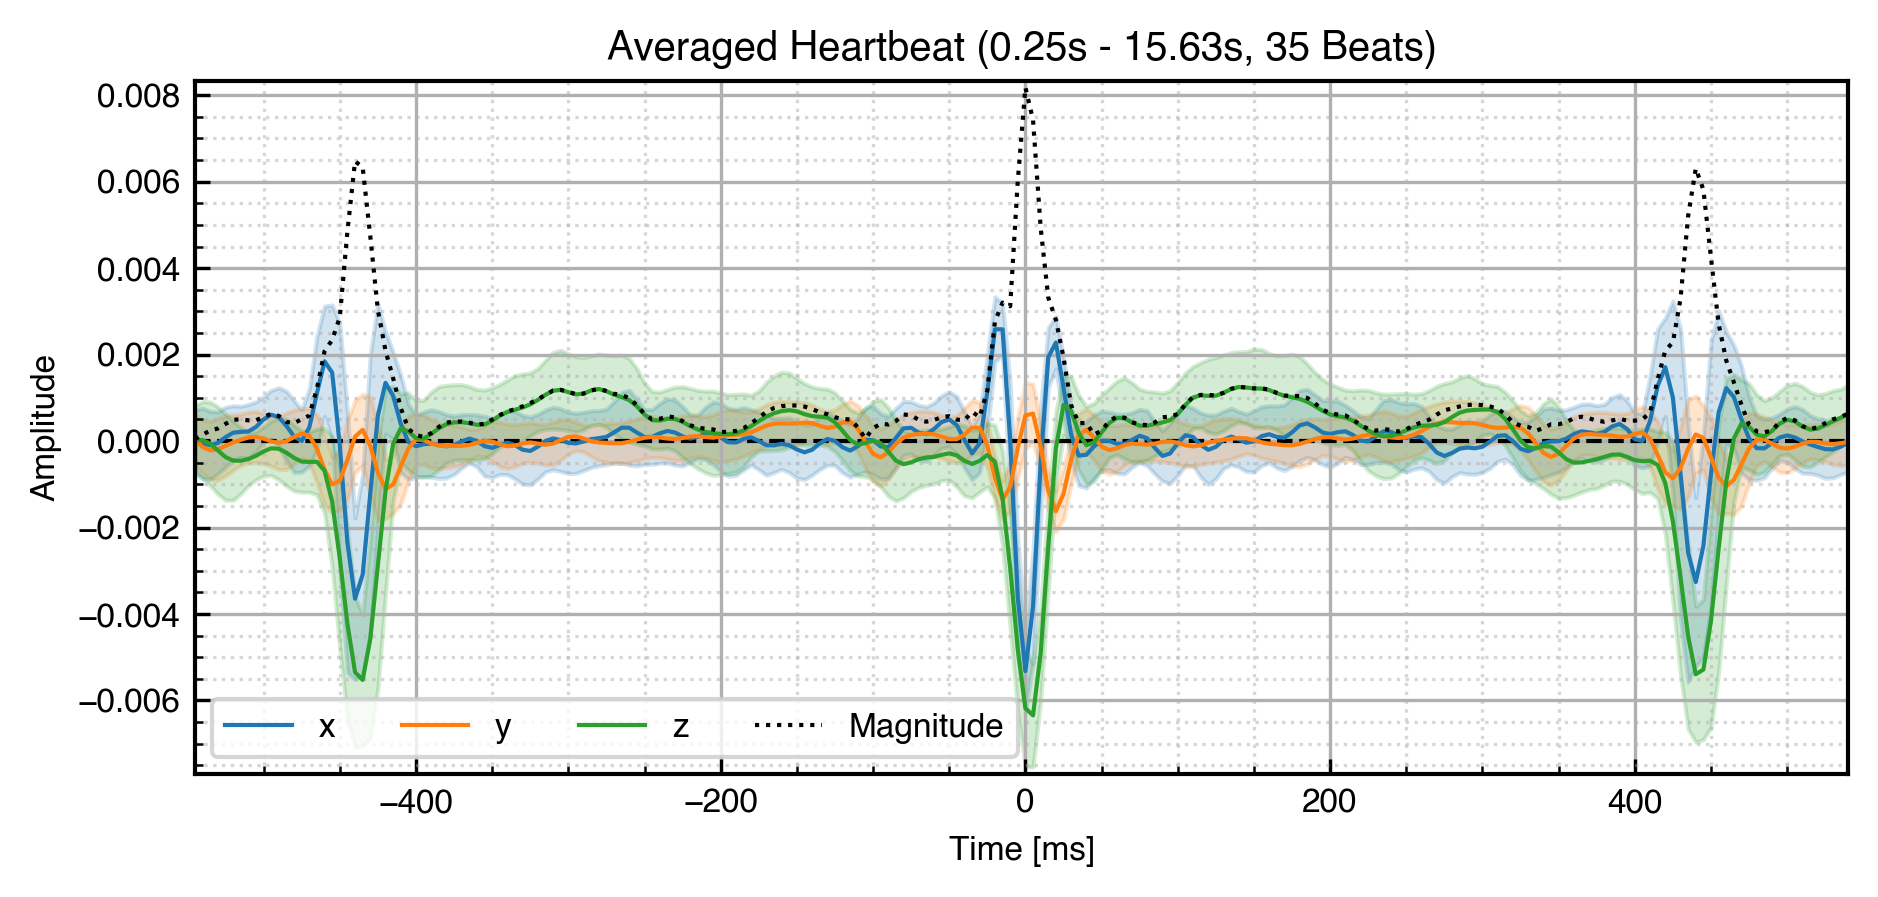

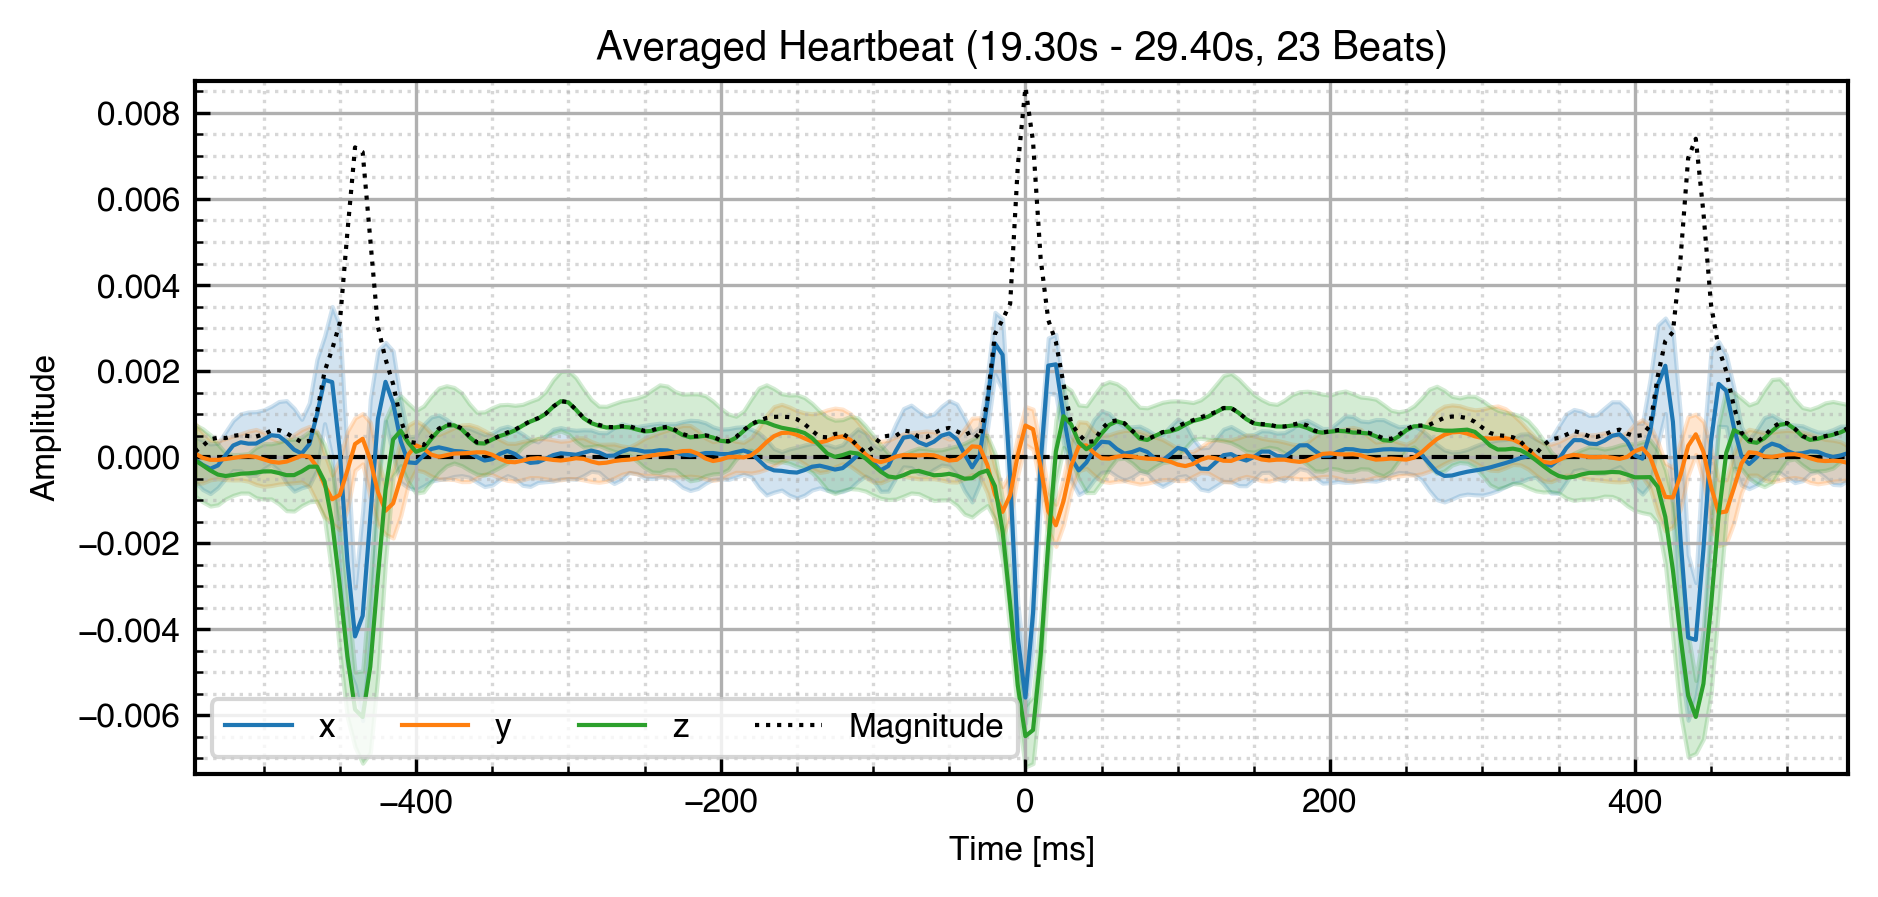

/jonas/fmcg/fmcg/analysis/heartbeat_averaging.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


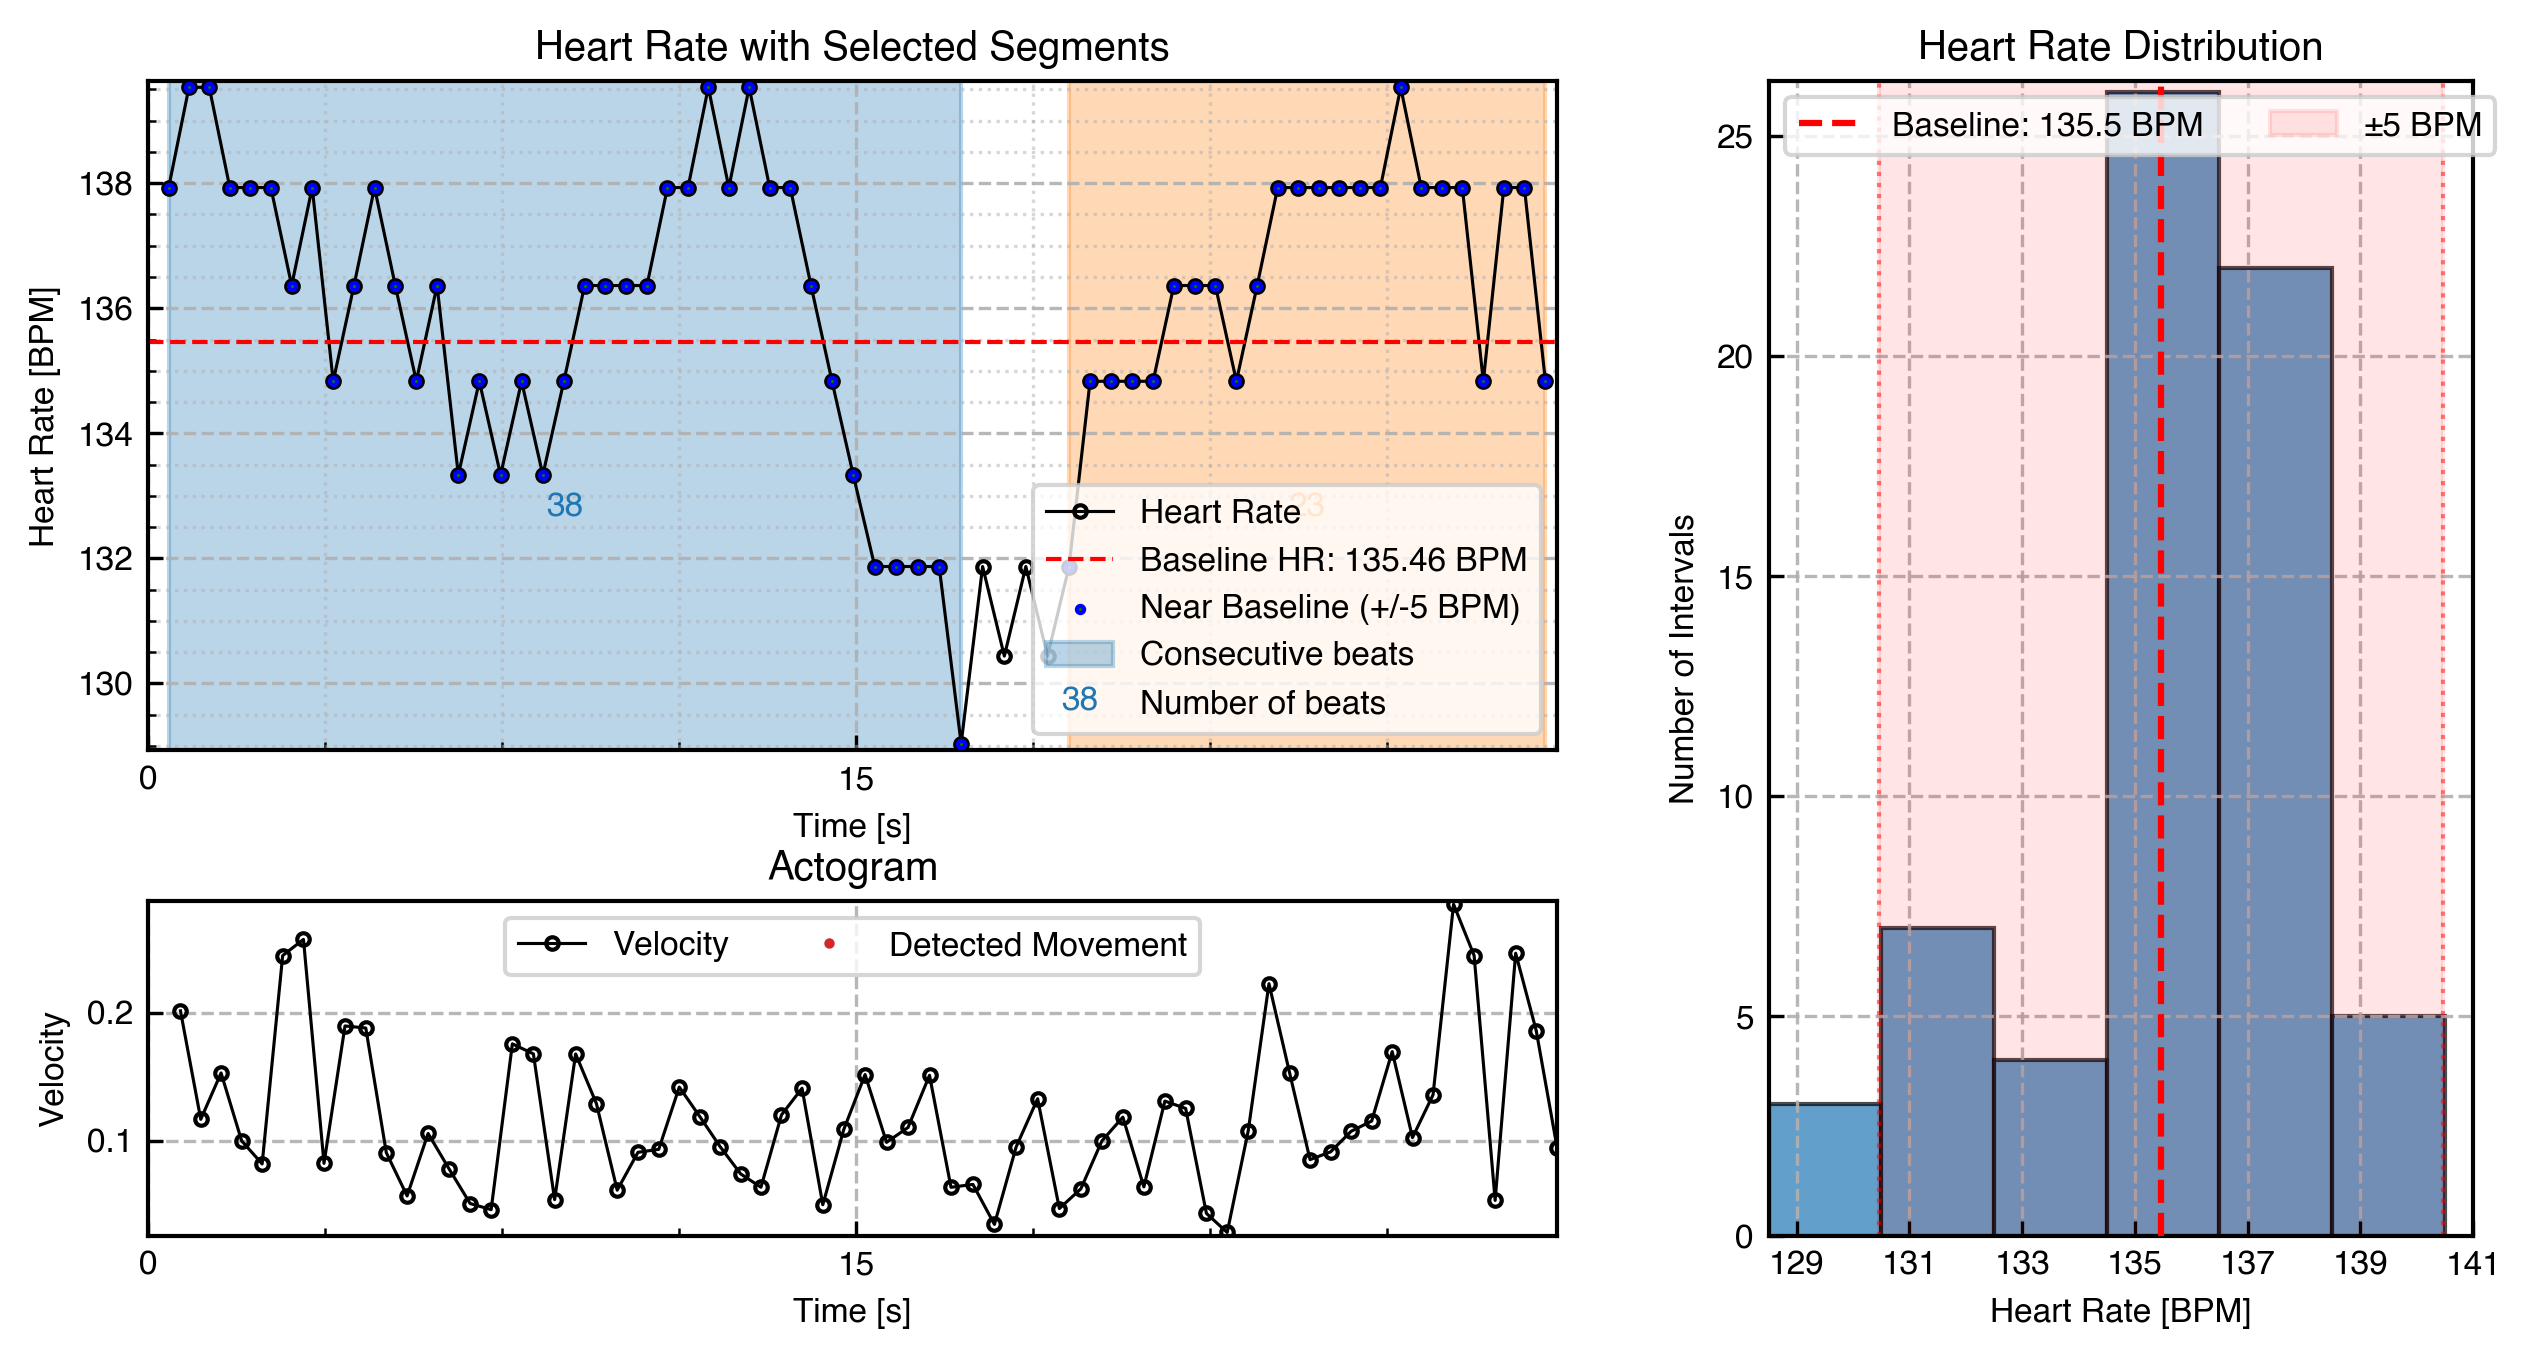

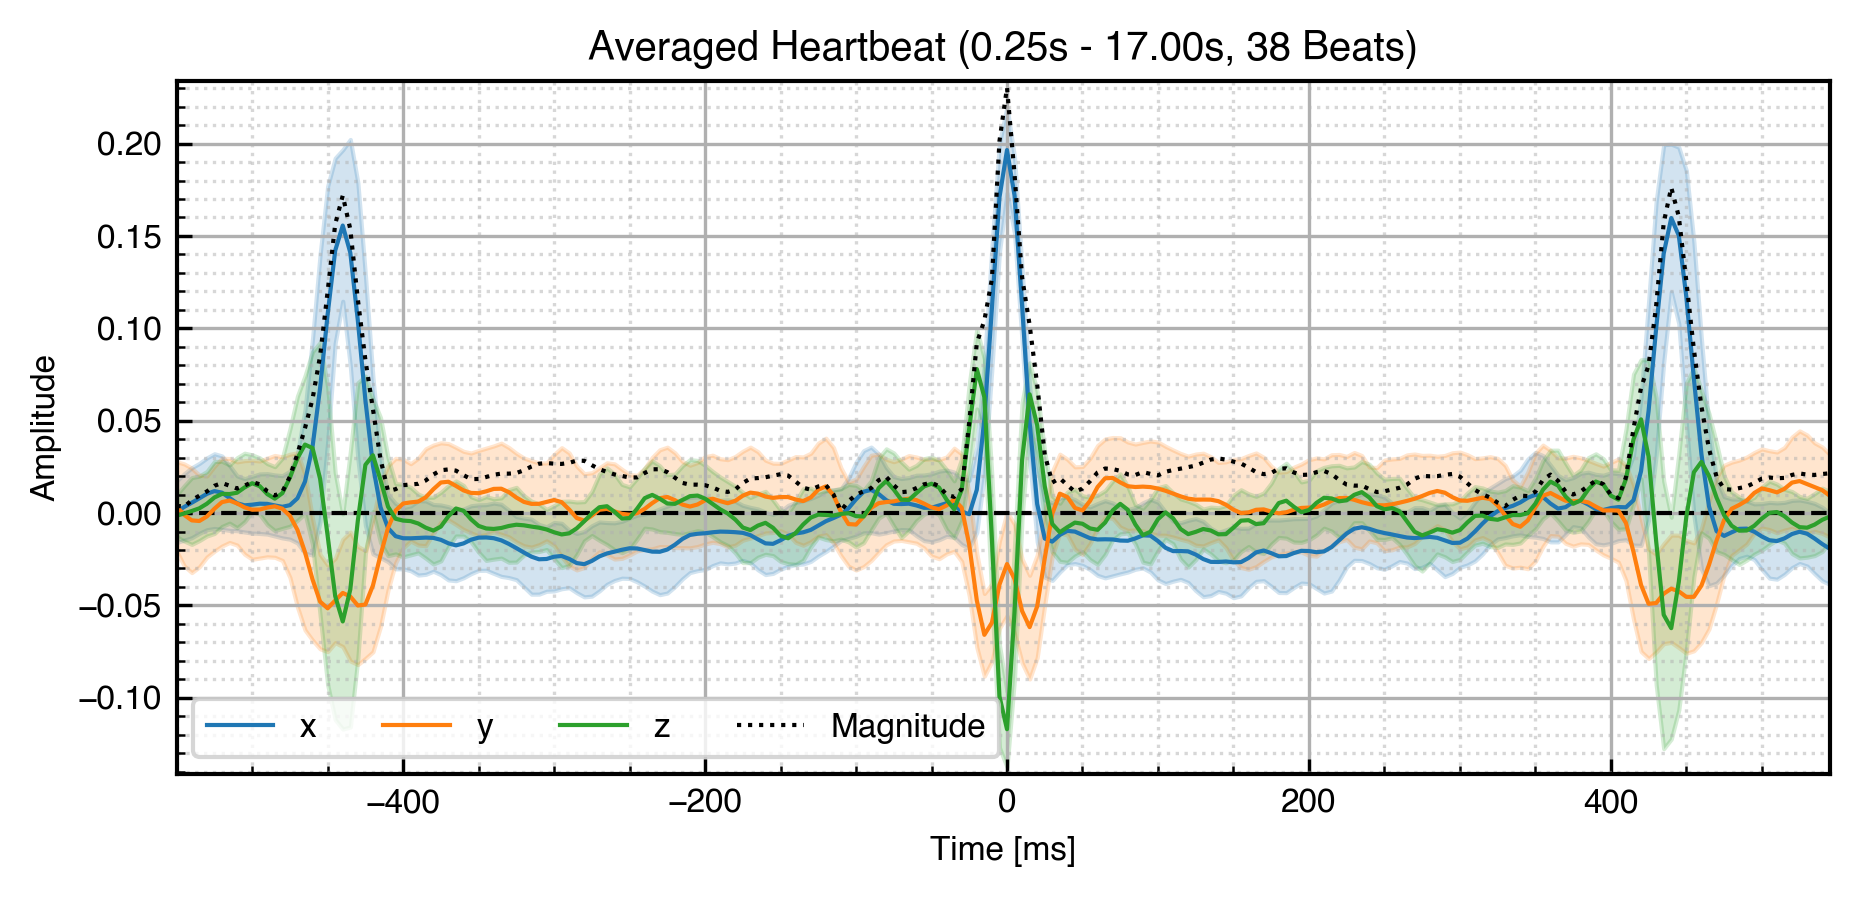

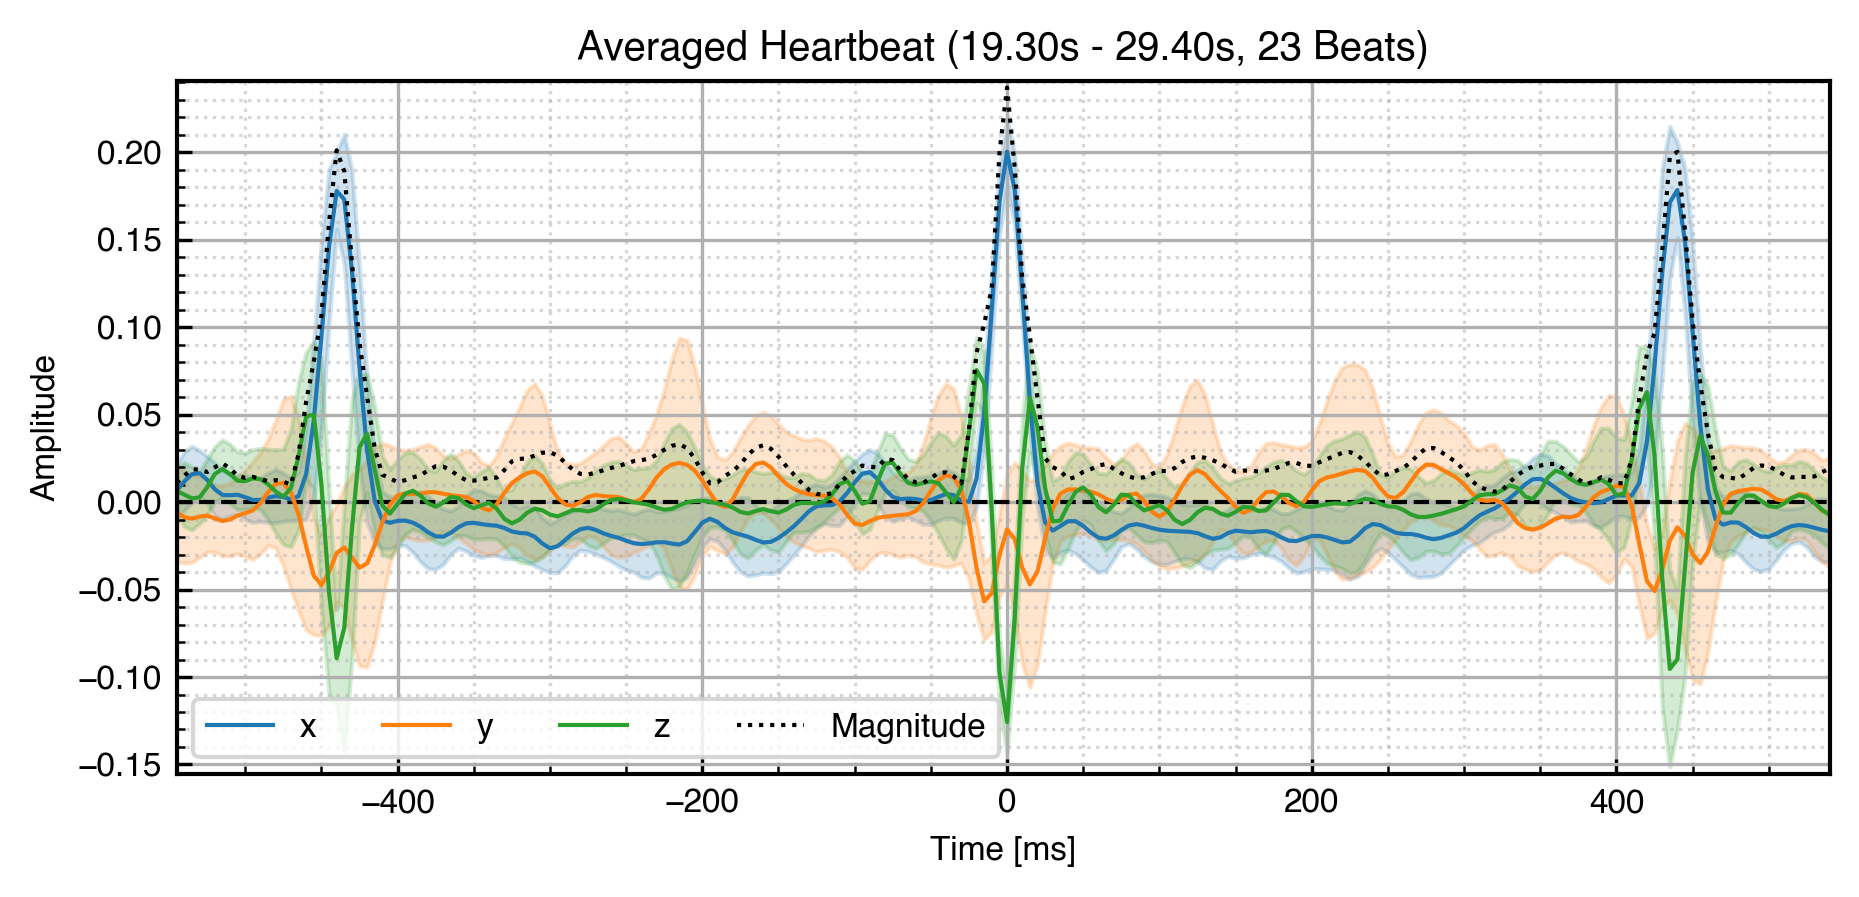

Magnetic-dipole fetal VCG


/jonas/fmcg/fmcg/utils/plotting/plot_utils.py:874: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(


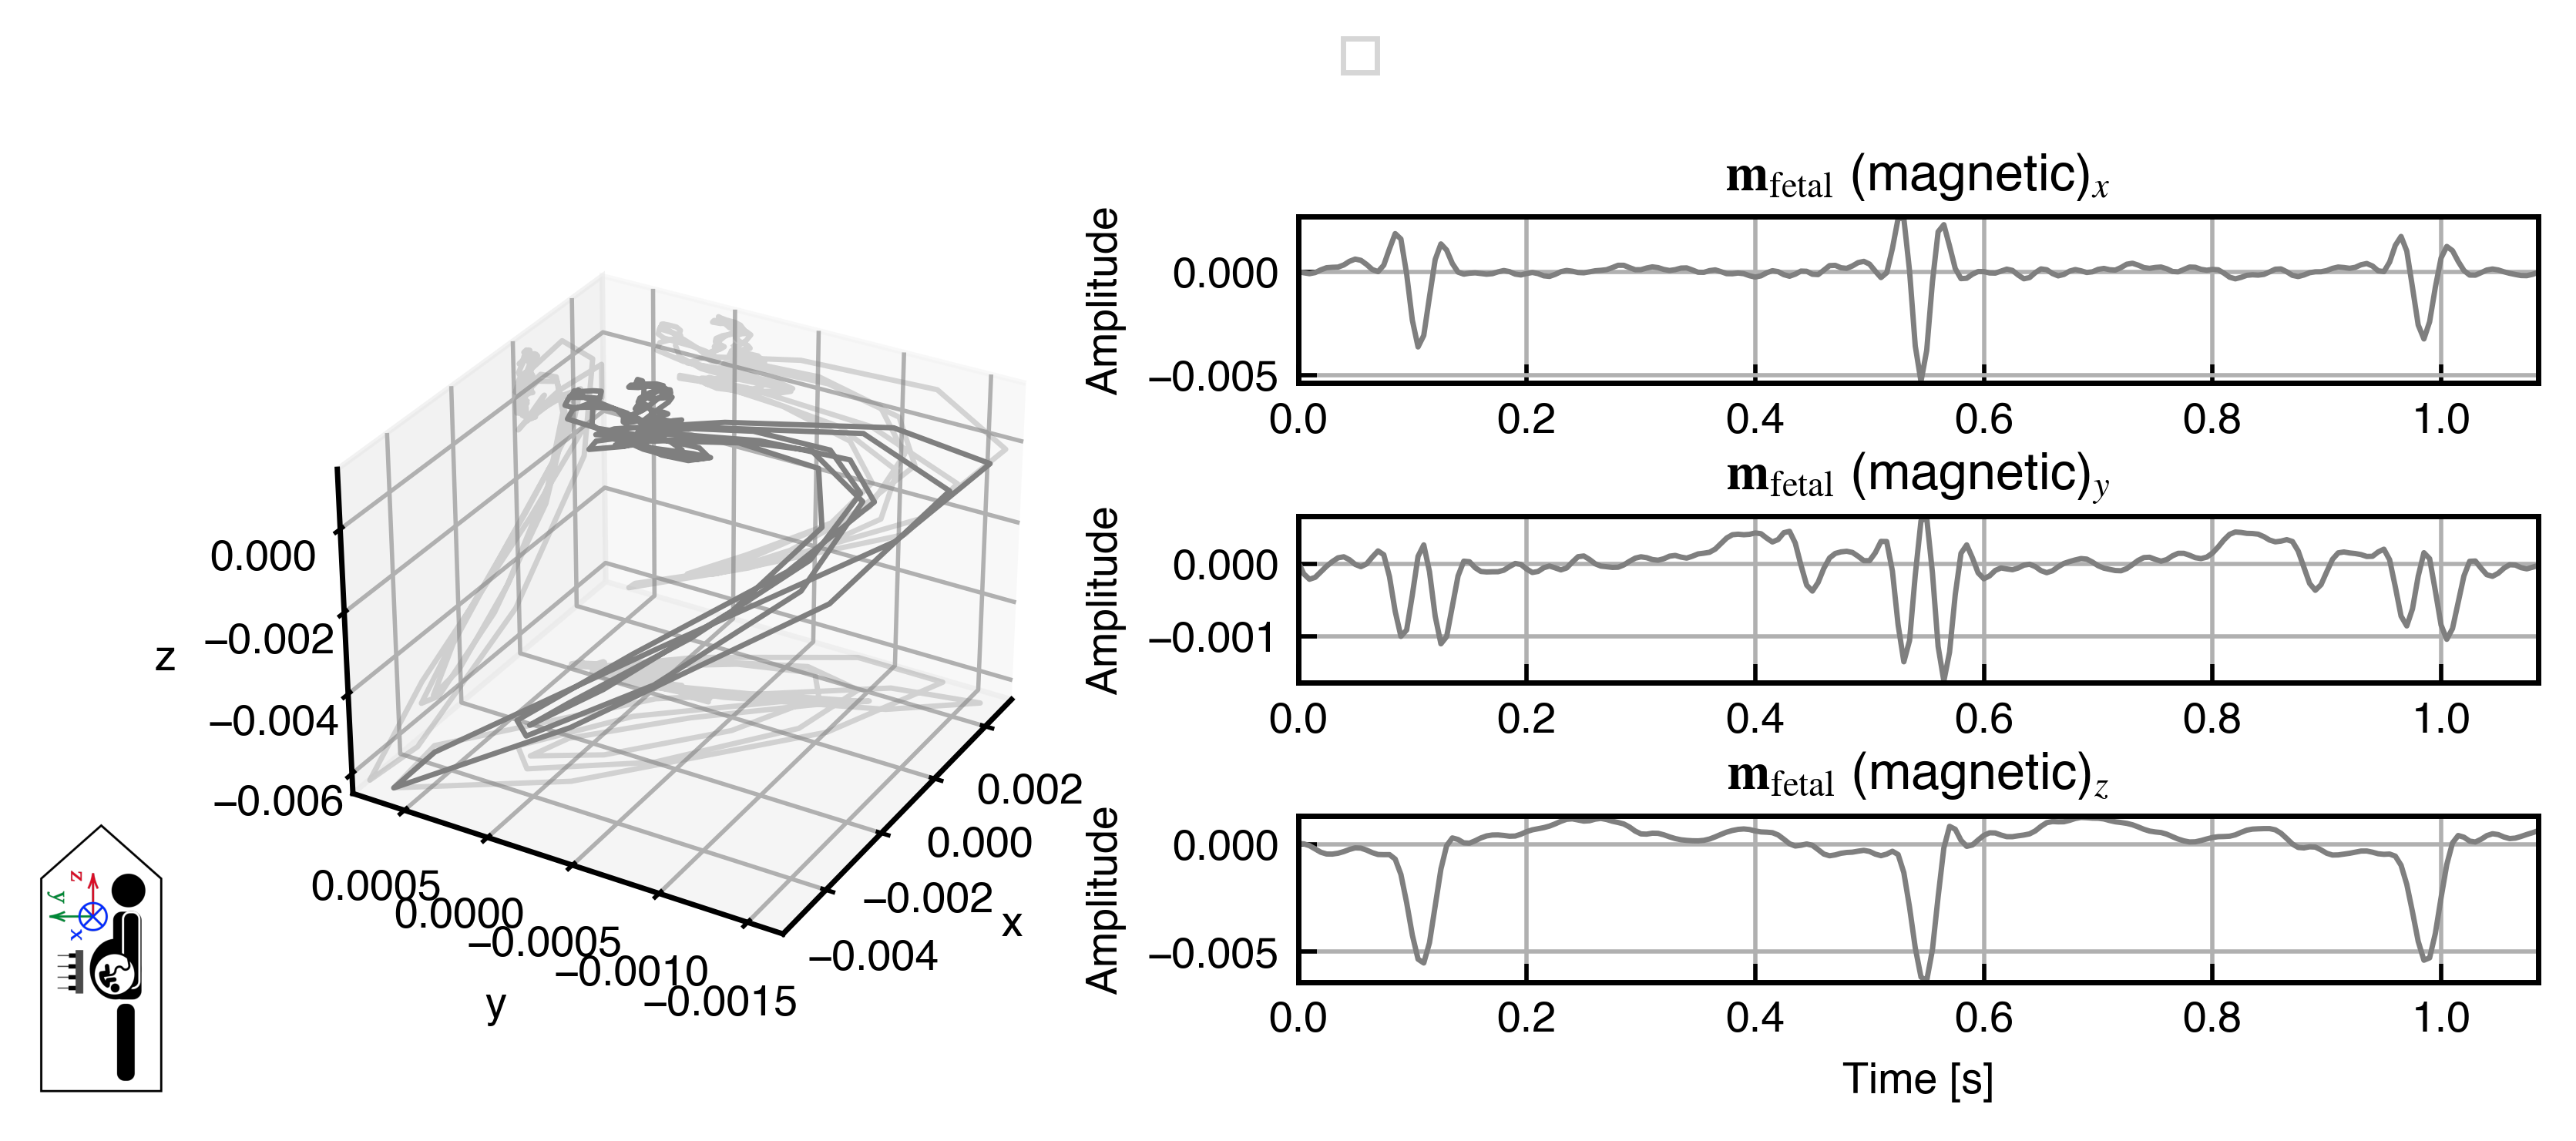

Current-dipole fetal VCG


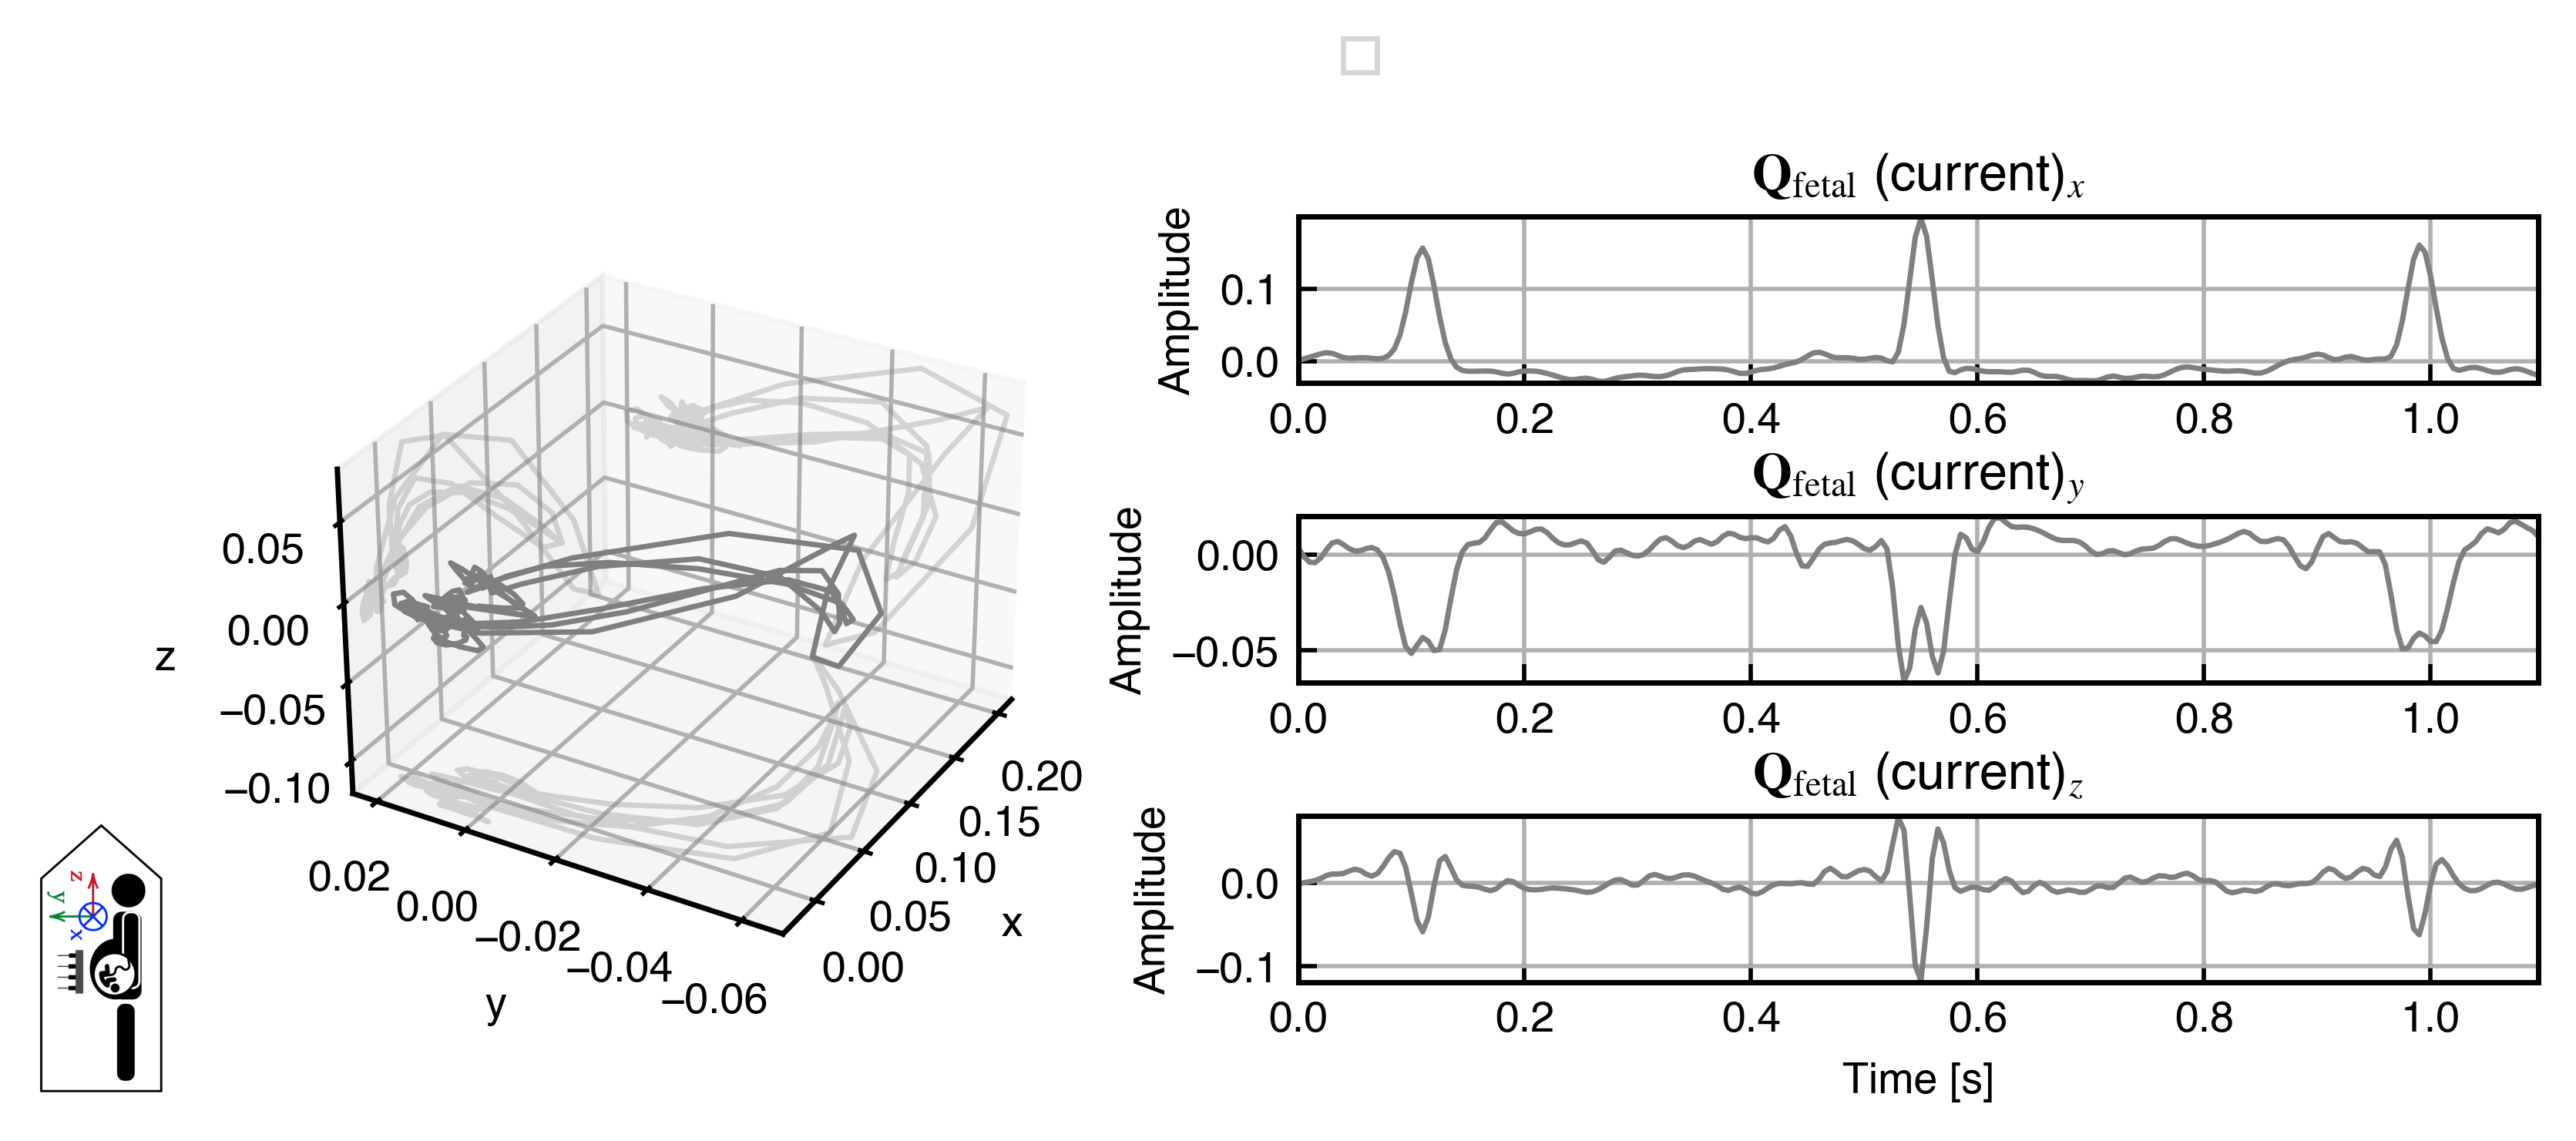

In [9]:
def averaged_fetal_beat(m_hat):
    _, peaks = compute_hr(m_hat[:, 0], fs, plot=False)
    avgs, _ = find_segments_and_average_heartbeats(peaks, m_hat[:, 0], fs)
    beat_mean, beat_std, beat_t = avgs[0]
    return beat_mean

beat_mag = averaged_fetal_beat(m_mag)
beat_cur = averaged_fetal_beat(m_cur)

print("Magnetic-dipole fetal VCG")
plot_vcg(beat_mag, None, fs=fs, sig_name=r"$\mathbf{m}_\text{fetal}$ (magnetic)")

print("Current-dipole fetal VCG")
plot_vcg(beat_cur, None, fs=fs, sig_name=r"$\mathbf{Q}_\text{fetal}$ (current)")

## Fitted positions and forward-fit residual (sanity)

Both models should localize to similar positions and explain the measured field about
equally well (comparable residual) — the difference is in the *moment representation*,
not the data fit.

magnetic dipole positions [m]:
  fetal:    [-0.017 -0.066 -0.011]
  maternal: [ 0.043 -0.186  0.223]


/jonas/fmcg/fmcg/utils/plotting/plot_utils.py:1565: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_fitted_cm[i, 0], r_fitted_cm[i, 2], r_fitted_cm[i, 1],
/jonas/fmcg/fmcg/utils/plotting/plot_utils.py:1588: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


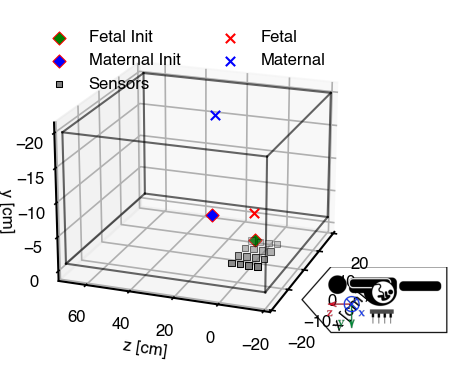

current dipole positions [m]:
  fetal:    [-0.017 -0.067 -0.035]
  maternal: [ 0.15  -0.005  0.223]


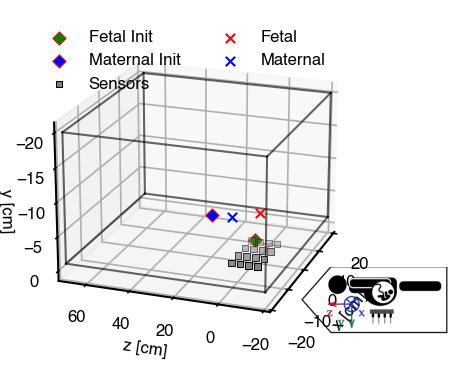

In [10]:
BOX_BOUNDS = np.array([
    [(-0.2, 0.2), (-0.2, -0.01), (-0.2, 0.2)],
    [(-0.4, 0.4), (-0.4, -0.01), (0.2, 0.7)],
]) * 100  # cm

for name, r_hat in [("magnetic", r_mag), ("current", r_cur)]:
    print(f"{name} dipole positions [m]:")
    print(f"  fetal:    {np.round(r_hat[0, 0], 3)}")
    print(f"  maternal: {np.round(r_hat[0, 1], 3)}")
    plot_dipole_positions_3d(
        r_fitted=r_hat, r_sensors=r_sensors, r_init=r_init, bounds=BOX_BOUNDS,
        time_idx=0, dpi=150, colors=['red', 'blue'], labels=['Fetal', 'Maternal'],
    )

---
**Notes.** The current-dipole model here is free-space Biot–Savart (no volume
conductor), the exact analogue of the free-space magnetic point dipole — they differ
only in angular dependence and falloff. To model the volume conductor, the spherical
(Sarvas) and BEM tiers are available in
`fMCG_simulator/physics_simulation/`. The `source_model` option can also be threaded
through `SolverConfig` for use from the `Pipeline` API.